Setup

In [13]:
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from time import time

import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TTF
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from IPython.display import clear_output


from dataloader import PH2DataLoader
from network import EncDec
from losses import bce_loss, dice_loss, focal_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


DataLoader

In [2]:
data_path = '/dtu/datasets1/02514/PH2_Dataset_images'

In [3]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 6
trainset = PH2DataLoader(transform=train_transform, data_path=data_path, train=True)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)

validationset = PH2DataLoader(transform=test_transform, data_path=data_path, validation=True)
validation_loader = DataLoader(validationset, batch_size=batch_size, shuffle=False, num_workers=3)

testset = PH2DataLoader(transform=test_transform, data_path=data_path)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

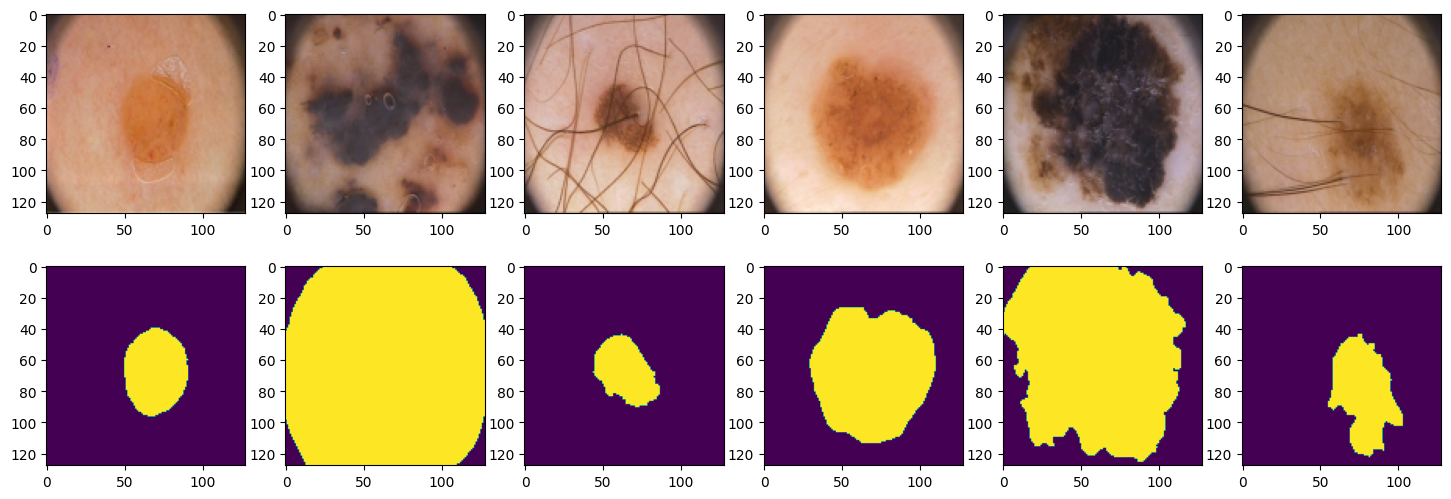

In [4]:
plt.rcParams['figure.figsize'] = [18, 6]

images, labels = next(iter(train_loader))

for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))

    plt.subplot(2, 6, i+7)
    plt.imshow(labels[i].squeeze())
plt.show()

# Train

In [ ]:
def get_iou(ground_truth, pred):
    # coordinates of the area of intersection.
    ix1 = np.maximum(ground_truth[0], pred[0])
    iy1 = np.maximum(ground_truth[1], pred[1])
    ix2 = np.minimum(ground_truth[2], pred[2])
    iy2 = np.minimum(ground_truth[3], pred[3])
     
    # Intersection height and width.
    i_height = np.maximum(iy2 - iy1 + 1, np.array(0.))
    i_width = np.maximum(ix2 - ix1 + 1, np.array(0.))
     
    area_of_intersection = i_height * i_width
     
    # Ground Truth dimensions.
    gt_height = calground_truth[3] - ground_truth[1] + 1
    gt_width = ground_truth[2] - ground_truth[0] + 1
     
    # Prediction dimensions.
    pd_height = pred[3] - pred[1] + 1
    pd_width = pred[2] - pred[0] + 1
     
    area_of_union = gt_height * gt_width + pd_height * pd_width - area_of_intersection
     
    iou = area_of_intersection / area_of_union
     
    return iou

In [ ]:
def IOU(TP, FP, FN):
    return TP / (TP + FN + FP)

In [ ]:
def accuracy(TP, TN, FP, FN):
    return (TP + TN) / (TP + FP + TN +FN)

In [ ]:
def sensitivity(TP, FN):
    return TP / (TP + FN)

In [ ]:
def specificity(TN, FP):
    return TN / (FP + TN) 

In [ ]:
iou_vals = []
acc_vals = []
sens_vals = []
spec_vals = []

In [5]:
def train(model, opt, loss_fn, epochs, train_loader, validation_loader):
    X_validation, Y_validation = next(iter(validation_loader))

    for epoch in range(epochs):
        TP_train = 0
        TN_train = 0
        FP_train = 0
        FN_train = 0
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)

        for data, targets in train_loader:
            data = data.to(device)
            for target in targets:
                target = target.to(device)
            
                output = model(data)
                #print(output > 0.5)
                predicted = torch.where(output > 0.5, 1, 0)

                TP_train += torch.sum(torch.where((target == 1) & (predicted == 1), 1, 0))
                TN_train += torch.sum(torch.where((target == 0) & (predicted == 0), 1, 0))
            
                FP_train += torch.sum(torch.where((target == 0) & (predicted == 1), 1, 0))
                FN_train += torch.sum(torch.where((target == 1) & (predicted == 0), 1, 0))

        #print(f"TP_train is {TP_train}")
        iou = IOU(TP_train, FP_train, FN_train)
        acc = accuracy(TP_train, TN_train, FP_train, FN_train)
        sens = sensitivity(TP_train, FN_train)
        spec = specificity(TN_train, FP_train)
        #print(f"IOU is {iou}, accuracy is {acc}, sensitivity is {sens}, specificity is {spec}")
        
        iou_vals.append(iou)
        acc_vals.append(acc)
        sens_vals.append(sens)
        spec_vals.append(spec)

        toc = time()
        print(' - loss: %f' % avg_loss)

        # show intermediate results
        model.eval()  # testing mode
        Y_hat = F.sigmoid(model(X_validation.to(device))).detach().cpu()
        clear_output(wait=True)
        for k in range(6):
            plt.subplot(2, 6, k+1)
            plt.imshow(np.rollaxis(X_validation[k].numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 6, k+7)
            plt.imshow(Y_hat[k, 0], cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()
        print(f"IOU is {iou}, accuracy is {acc}, sensitivity is {sens}, specificity is {spec}")

# Model

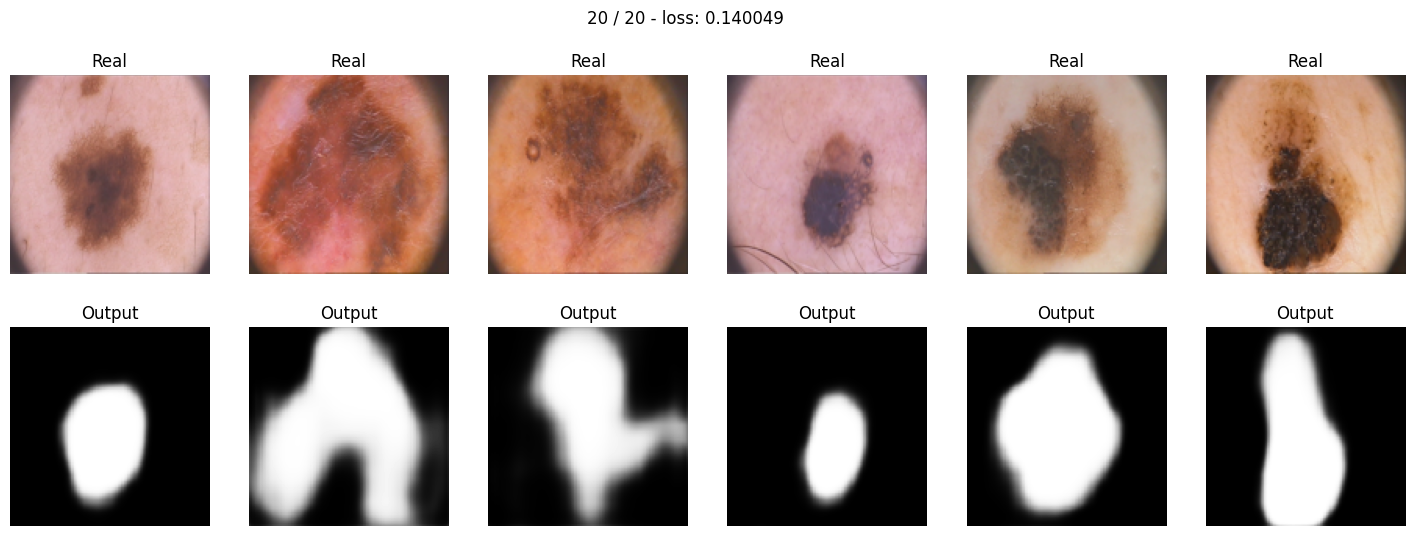

In [14]:
model = EncDec().to(device)
train(model, optim.Adam(model.parameters()), bce_loss, 20, train_loader, test_loader)

In [ ]:
#print(iou_vals)
iou_vals2 = [value.cpu().data.numpy() for value in iou_vals]
acc_vals2 = [value.cpu().data.numpy() for value in acc_vals]
sens_vals2 = [value.cpu().data.numpy() for value in sens_vals]
spec_vals2 = [value.cpu().data.numpy() for value in spec_vals]
#print(iou_vals2)

plt.plot(range(len(iou_vals2)), iou_vals2)
#plt.plot(range(len(self.out_dict["train_acc"])), self.out_dict["train_acc"])
#plt.legend(('IOU'))
plt.xlabel('Epoch number')
plt.ylabel('IOU')
plt.show()


plt.plot(range(len(acc_vals2)), acc_vals2)
#plt.legend(('Accuracy'))
plt.xlabel('Epoch number')
plt.ylabel('Accuracy')
plt.show()


plt.plot(range(len(sens_vals2)), sens_vals2)
#plt.legend(('Sensititiv'))
plt.xlabel('Epoch number')
plt.ylabel('Sensitivity')
plt.show()


plt.plot(range(len(spec_vals2)), spec_vals2)
#plt.legend(('Test error','Train eror'))
plt.xlabel('Epoch number')
plt.ylabel('Specificity')
plt.show()

In [ ]:
def predict(model, test_loader):
    model.eval()  # testing mode
    for X_batch, Y_batch in 
    Y_pred = [F.sigmoid(model(X_batch.to(device))) for X_batch, _ in test_loader]
    return np.array(Y_pred)

In [ ]:
model = UNet().to(device)
summary(model, (3, 256, 256))